Logistic Regression — Single Feature

Single-feature logistic regression is a classification model that uses only one independent variable to predict a binary outcome (0 or 1).

1. Imports


Dataset= Heart_disease_prediction
model= single feature logistic regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

2. Data Retrieval and Collection

The heart disease dataset is loaded from a CSV file into a pandas DataFrame. This step collects the data needed to train and test the machine learning model.

Feature (X): Age
Target (Y): Heart Disease (Yes/No)

The model learns the relationship between age and the probability of having heart disease.
P(Y=1)=1/(1+e−(b0​+b1​X))

In [2]:
# Load the Heart Disease dataset

# Alternative simpler approach (commented out):
# def load_dataset(filepath):
#     df = pd.read_csv(filepath)
#     return df

def load_dataset(filepath):
    # Using a context manager ensures the file is closed properly after reading
    with open(filepath, 'r') as f:
        df = pd.read_csv(f)
        return df

df = load_dataset('Heart_Disease_Prediction.csv')

3. Data Exploration

We look at the datasets shape, column names, some sample records and a statistical summary. This helps us understand the datasets structure, features and overall characteristics.

In [3]:
# Display dataset shape and column names
def display_info(df):
    print('Dataset Shape:', df.shape)
    print('Column Names:', df.columns.tolist())
    print(df.head(5))

display_info(df)

Dataset Shape: (270, 14)
Column Names: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4    

In [4]:
# Brief statistical summary of the dataset
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


4. Data Cleaning and Preprocessing

The dataset is checked for missing values, duplicate records and incorrect data types. Then the data is converted into the formats to ensure consistency and improve the models performance.

In [5]:
# Check for missing and duplicate values
def check_missing(df):
    null_val = df.isnull().sum()   # count null values per column
    dup_val  = df.duplicated().sum()  # count duplicate rows
    return null_val, dup_val

check_missing(load_dataset('Heart_Disease_Prediction.csv'))

(Age                        0
 Sex                        0
 Chest pain type            0
 BP                         0
 Cholesterol                0
 FBS over 120               0
 EKG results                0
 Max HR                     0
 Exercise angina            0
 ST depression              0
 Slope of ST                0
 Number of vessels fluro    0
 Thallium                   0
 Heart Disease              0
 dtype: int64,
 np.int64(0))

In [6]:
# Ensure the target variable is binary (exactly 2 unique values)
df['Heart Disease'].nunique() == 2

True

In [7]:
# Verify and cast column data types as needed
df.dtypes

if df.dtypes['Heart Disease'] != 'str':
    df['Heart Disease'] = df['Heart Disease'].astype(str)

if df.dtypes['Age'] != 'int64':
    df['Age'] = df['Age'].astype(int)

# Repeat for remaining columns as needed

5. Feature Design and Selection

The Cholesterol feature is selected as the input variable and Heart Disease is selected as the target variable. A box plot is used to see how cholesterol levels relate to heart disease status. The Cholesterol feature helps predict Heart Disease.


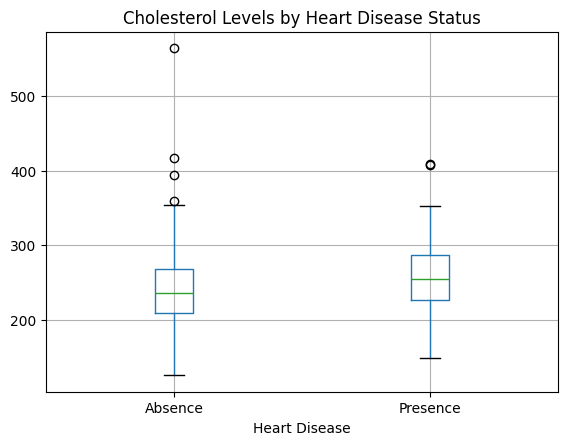

In [8]:
# Select feature (X) and target (Y)
# Double brackets [[ ]] keep X as a 2D DataFrame — required by sklearn
X = df[['Cholesterol']]   # single feature: Cholesterol
Y = df['Heart Disease']

# Visualise the relationship between Cholesterol and Heart Disease
# A box plot is more appropriate here because the target is binary
df.boxplot(column='Cholesterol', by='Heart Disease')
plt.title('Cholesterol Levels by Heart Disease Status')
plt.suptitle('')   # remove the default auto-generated suptitle
plt.show()

# Observation: patients with higher cholesterol tend to have heart disease,
# suggesting Cholesterol is a reasonable predictor.
# We will quantify this relationship with logistic regression.

6. Algorithm — Logistic Regression

Logistic Regression is used because it is good for classification problems. The dataset is split into training and testing sets. The model learns how cholesterol levels relate to heart disease occurrence. Logistic Regression works with Heart Disease data.


In [9]:
# Split data into training (80 %) and testing (20 %) sets
# random_state=42 ensures reproducibility across runs
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print('Training set shape:', X_train.shape, Y_train.shape)
print('Testing set shape: ', X_test.shape,  Y_test.shape)
print(X_test.head(5))
print(Y_test.head(5))

Training set shape: (216, 1) (216,)
Testing set shape:  (54, 1) (54,)
     Cholesterol
30           229
116          249
79           236
127          196
196          248
30     Presence
116    Presence
79      Absence
127     Absence
196     Absence
Name: Heart Disease, dtype: object


In [10]:
# Confirm shapes — X should be (n_samples, 1) because we used double brackets
# No manual reshaping is needed since df[['Cholesterol']] is already 2-D
#
#   X_train = X_train.values.reshape(-1, 1)  ← not required
#   X_test  = X_test.values.reshape(-1, 1)   ← not required

print('X_train shape:', X_train.shape)   # expected (216, 1)
print('X_test  shape:', X_test.shape)    # expected  (54, 1)
print('Y shapes      :', Y_train.shape, Y_test.shape)

# Y is already 1-D (n_samples,) — correct format for sklearn

X_train shape: (216, 1)
X_test  shape: (54, 1)
Y shapes      : (216,) (54,)


In [11]:
# Train the logistic regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train, Y_train)

# The model learns the relationship between Cholesterol levels
# and Heart Disease presence, enabling predictions on new data.

LogisticRegression()


7. Model Evaluation

The trained model is evaluated using Accuracy, Precision, Recall and F1-Score. A confusion matrix is generated to compare actual and predicted classifications of Heart Disease.


In [12]:
# Compute classification metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, log_loss
)

Y_pred = logistic_model.predict(X_test)

accuracy  = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred, pos_label='Presence')
recall    = recall_score(Y_test,    Y_pred, pos_label='Presence')
f1        = f1_score(Y_test,        Y_pred, pos_label='Presence')

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')

# Confusion matrix (rows = actual, cols = predicted)
conf_matrix = confusion_matrix(Y_test, Y_pred, labels=['Presence', 'Absence'])
print('\nConfusion Matrix:\n', conf_matrix)

Accuracy : 0.6111
Precision: 0.5000
Recall   : 0.2381
F1 Score : 0.3226

Confusion Matrix:
 [[ 5 16]
 [ 5 28]]


8. Loss Function — Binary Cross-Entropy (Log Loss)

Binary Cross-Entropy measures how well the predicted probabilities match the class labels of Heart Disease. Lower values indicate model performance and more accurate probability predictions, for Heart Disease.

In [13]:
# Predict class probabilities and compute log loss
Y_prob = logistic_model.predict_proba(X_test)  # shape: (n_samples, 2)
loss   = log_loss(Y_test, Y_prob, labels=['Absence', 'Presence'])

print(f'Log Loss: {loss:.6f}')

Log Loss: 0.660867
